# Post-Training Evaluation: Using the Trained Agent

This notebook walks through how to use a trained DDQN agent to discover circuits for EIS data.

## What You'll Learn
1. How to load a trained model
2. How to generate an ECM for a single EIS (detailed walkthrough)
3. Step-by-step agent decision process
4. Batch evaluation on multiple EIS
5. Analyzing and visualizing results
6. Comparing discovered circuits vs ground truth

## Prerequisites
- Trained model (from 02_training_walkthrough.ipynb)
- Dataset with EIS measurements

In [1]:
# Configure runtime to prevent kernel crashes from TensorFlow/JAX and JuliaCall import conflicts.
from autorec.runtime import configure_autorec_runtime

configure_autorec_runtime()

PosixPath('/home/yonatank/.cache/autorec_eis')

In [2]:
# Configure threading
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = (
    "3"  # Suppress TensorFlow logging (1: INFO, 2: WARNING, 3: ERROR) - example: you are using different TensorFlow than the trained model you are loading
)

# Imports
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import autoeis as ae

from autorec.utils import set_global_seed

set_global_seed(42, deterministic_ops=True)

from autorec.data_preparation import EISDataPrep
from autorec.environment import EIS_ECM_Env
from autorec.agent import DDQN_ECM
from autorec.utils import parse_state_to_circuit, draw_circuit_png, plot_bar

I0000 00:00:1779736099.920647   15619 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779736102.857477   15619 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Global seed set to 42
Deterministic operations: True


---
## Step 1: Load Data and Setup Environment

Check the `01_data_preparation_walkthrough.ipynb` file to see how you can create this pkl file containing the proccessed EIS data.



In [3]:
# Load dataset
data_prep = EISDataPrep(path="../data/examples/training_dataset.pkl", evaluation=True)

dataset = data_prep.load()
print(f"Loaded {len(dataset)} EIS measurements")


Validation Warnings:
  ⚠ Dataset contains extra columns (will be ignored): Z_perfect, Z_perfect_flatten, chi_LinKK, r2_LinKK, chi_fit, r2_fit, true_state
  ⚠ Column 'sub_id' should contain string values

✓ Validation passed (1350 samples)
Loaded 1350 EIS measurements


In [4]:
# Create environment (same as training)
env = EIS_ECM_Env(dataset=dataset, seed=42, chromosome_HEAD_len=10, cache_enabled=True)

action_cap = env.chromosome_HEAD_len + env.chromosome_TAIL_len + 3
print(f"Environment ready. Action cap: {action_cap}")

✓ Circuit evaluation cache enabled: LRU with capacity 20,000
Environment ready. Action cap: 24


---
## Step 2: Load Trained Model

In [ ]:
# Create agent with same architecture as training

DIR = "./demo_output"  # Directory where the output will be saved for this demo

agent = DDQN_ECM(
    training_env=env,
    save_dir=DIR,
    action_cap=action_cap,
    num_trials=1,  # Doesn't matter for evaluation
)

# Load the trained model
model_path = "../models/examples/agent_trained.keras"
# Or use your actual model path:
# model_path = "path/to/your/model.keras"

agent.load_model(model_path)

input shape:  (None, 442)
output shape:  (None, 80)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 442)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 40)             │        17,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 40)             │         1,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 80)             │         3,280 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,640 (88.44 KB)

 Trainable params: 22,640 (88.44 KB)

 Non-trainable params: 0 (0.00 B)

Model summary saved to demo_output/model_summary.txt
✓ Model loaded from: ../trained_agent/agent_trained.keras


---
## Step 3: Single EIS Walkthrough 

Let's walk through the complete process of discovering a circuit for one EIS measurement.

### 3.1: Select an EIS to Work With

In [6]:
# Select a random EIS
test_eis_idx = np.random.randint(0, len(dataset))
# Or choose a specific one:
# test_eis_idx = 42

eis_data = dataset.iloc[test_eis_idx]

print(f"Selected EIS #{test_eis_idx}")
print(f"  Sub ID: {eis_data['sub_id']}")
if "true_circuit" in eis_data:
    print(f"  True circuit: {eis_data['true_circuit']}")
print(f"  Chi² threshold: {eis_data['chi_thresh']:.4f}")
print(f"  R² threshold: {eis_data['r2_thresh']:.4f}")

Selected EIS #660
  Sub ID: 660
  True circuit: R1-[R2-[R3,C4],C5]
  Chi² threshold: 0.0000
  R² threshold: 0.9998


### 3.2: Visualize the Target EIS

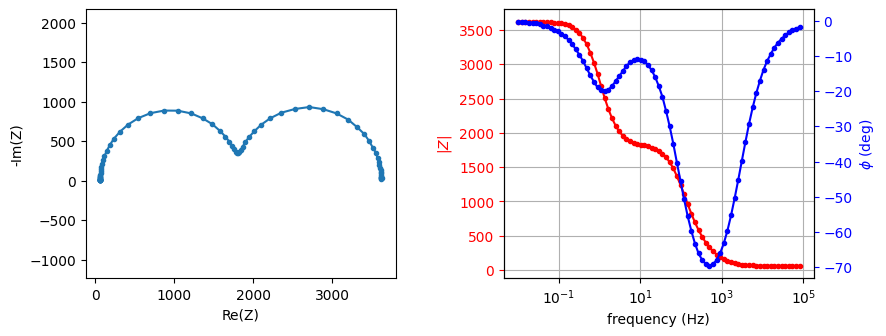

In [7]:
# Plot Nyquist and Bode plots
Z = eis_data["Z_true"]
freq = eis_data["freq"]

ax = ae.visualization.plot_impedance_combo(freq, Z)

### 3.3: Generate ECM for the selected single EIS

The agent.generate_ECM() function produces the ECM from sequential decisions made by the trained agent. 
- The get_fit_plots option produce the Nyquist fit plot for the final step in the `fit_plots` folder.  
- The gif_generation option produce the GIF file showing the Step-by-Step agent's Decision Process and store it in the `generated_circuits` folder.

In [8]:
eval_result = agent.generate_ECM(
    EIS_i=test_eis_idx, max_actions=20, get_fit_plots=True, gif_generation=True
)


True Circuit: R1-[R2-[R3,C4],C5]

✓ Found good fit at action 4!
  Circuit: R1-[P2,[P3,R4]-R5]
  Coding: +/R+PR/RP
  Reward: 10.2914
  Metrics:
    r2_score: 0.999995
    r2_mag: 0.999998
    r2_phase: 0.999993

Evaluation Summary:
  Solution Found: True
  Best Reward: 10.2914
  Actions Taken: 5/20
  Best Circuit: R1-[P2,[P3,R4]-R5]


Preparing circuit evolution data for EIS 660...
Generating circuit evolution GIF...
  Processing circuit 1/5: R1-[R2,R3]
    ✓ Frame saved (R²: -0.3844, χ²: 28.7918, passed: False)
  Processing circuit 2/5: R1-[P2,R3]
    ✓ Frame saved (R²: 0.8112, χ²: 0.0571, passed: False)
  Processing circuit 3/5: R1-[P2,R3-R4]
    ✓ Frame saved (R²: 0.8112, χ²: 0.0571, passed: False)
  Processing circuit 4/5: R1-[P2,[R3,R4]-R5]
    ✓ Frame saved (R²: 0.8112, χ²: 0.0571, passed: False)
  Processing circuit 5/5: R1-[P2,[P3,R4]-R5]
    ✓ Final frame saved to: demo_output/generated_circuits/final_circuits/final_circuit_EIS_660.png
    ✓ Frame saved (R²: 1.0000, χ²: 0.0000

### 3.5: Visualize the Agent's Journey

In [9]:
# Convert the agent's action history to a DataFrame for tabular visualization
history_df = pd.DataFrame(eval_result["action_history"])
history_df

,action,action_type,action_position,prev_state,new_state,coding,circuit,reward,validity,good_fit,metrics
0,0,/,1,+RRRRRRRRRRRRRRRRRRRR,+/RRRRRRRRRRRRRRRRRRR,+/RRR,"R1-[R2,R3]",-0.020000,1,False,"{'chi_square': 28.79175504872254, 'r2_score': ..."
1,1,P,4,+/RRRRRRRRRRRRRRRRRRR,+/RRPRRRRRRRRRRRRRRRR,+/RRP,"R1-[P2,R3]",0.010000,1,False,"{'chi_square': 0.057147599885837314, 'r2_score..."
2,2,+,3,+/RRPRRRRRRRRRRRRRRRR,+/R+PRRRRRRRRRRRRRRRR,+/R+PRR,"R1-[P2,R3-R4]",0.010000,1,False,"{'chi_square': 0.057147609931943684, 'r2_score..."
3,3,/,6,+/R+PRRRRRRRRRRRRRRRR,+/R+PR/RRRRRRRRRRRRRR,+/R+PR/RR,"R1-[P2,[R3,R4]-R5]",0.010000,1,False,"{'chi_square': 0.057147535871699705, 'r2_score..."
4,4,P,8,+/R+PR/RRRRRRRRRRRRRR,+/R+PR/RPRRRRRRRRRRRR,+/R+PR/RP,"R1-[P2,[P3,R4]-R5]",10.291426,1,True,"{'chi_square': 2.0943483171734845e-06, 'r2_sco..."


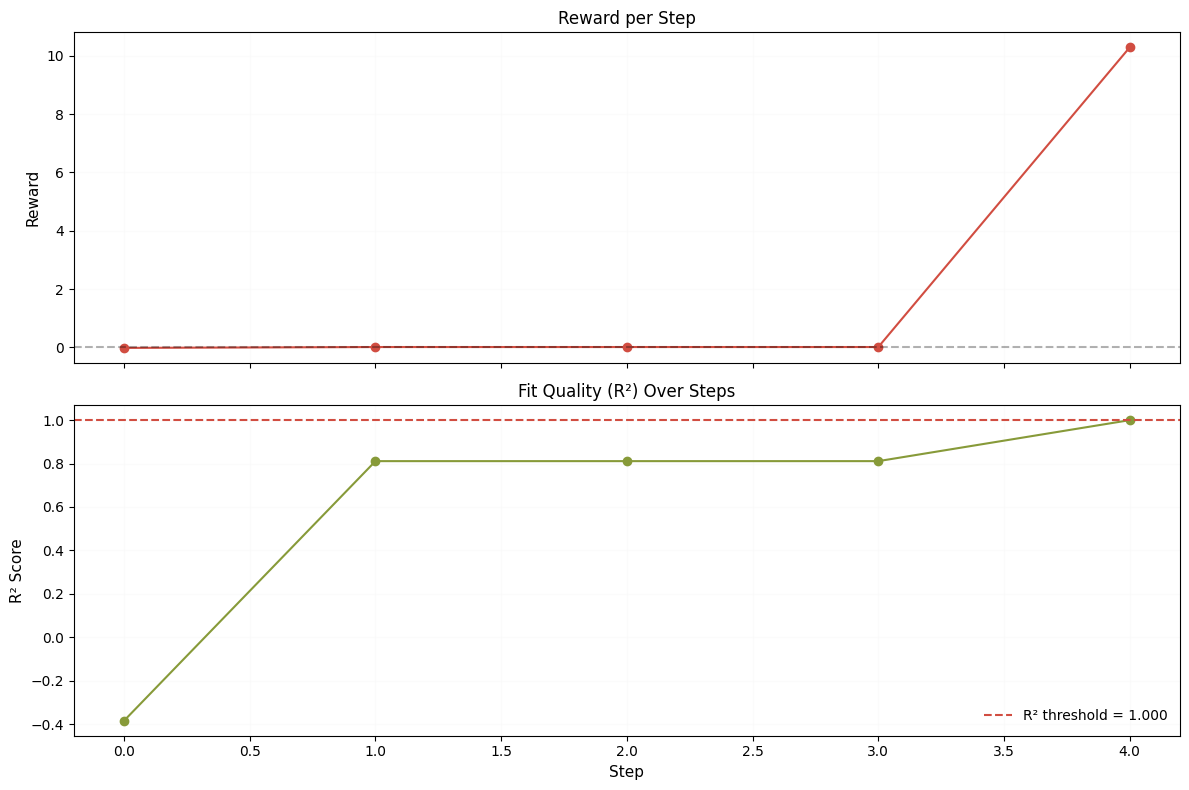

In [10]:
# Using this table, now you can plot the reward and fit metrics (here we use the R² score) over steps to visualize how the agent's performance evolved during the episode.

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Reward over steps
axes[0].plot(history_df["action"], history_df["reward"], "o-", markersize=6)
axes[0].set_ylabel("Reward")
axes[0].set_title("Reward per Step")
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color="k", linestyle="--", alpha=0.3)

# R² score over steps
r2_data = [row["r2_score"] for row in history_df["metrics"].dropna()]
if len(r2_data) > 0:
    axes[1].plot(history_df["action"], r2_data, "o-", markersize=6, color="green")
    axes[1].axhline(
        y=eis_data["r2_thresh"],
        color="r",
        linestyle="--",
        label=f"R² threshold = {eis_data['r2_thresh']:.3f}",
    )
    axes[1].set_ylabel("R² Score")
    axes[1].set_title("Fit Quality (R²) Over Steps")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

axes[1].set_xlabel("Step")
plt.tight_layout()
plt.show()

In [11]:
# Now based on the analysis above, you may want to draw the circuit corresponding to a specific step

selected_step = 2  # Change this to view different steps (note that steps starts from 0, so step 2 is actually the 3rd action taken by the agent)

selected_state = history_df.loc[selected_step, "new_state"]
circuit, _, coding = parse_state_to_circuit(selected_state)
draw_circuit_png(
    circuit, output_path=f"{DIR}/circuit_step_{selected_step}.png", dpi=300
)  # This will save the circuit diagram as "circuit_step_{selected_step}.png" in the current directory.

---
## Step 4: Batch Evaluation

Now let's evaluate the agent on multiple EIS measurements at once.

In [12]:
# Select random sample for evaluation
n_eval = 20  # Evaluate on 20 EIS
eval_indices = np.random.choice(len(dataset), size=n_eval, replace=False).tolist()

print(f"Evaluating on {n_eval} random EIS measurements...")
print("This may take a few minutes...\n")

# Run batch evaluation
eval_results = agent.eval_batch_eis(
    eis_indices=eval_indices,
    max_actions=action_cap,
    verbose=False,  # Set to True to see progress for each EIS
)

print("\n✓ Evaluation complete!")
print(f"Evaluated {len(eval_results)} EIS measurements")

Evaluating on 20 random EIS measurements...
This may take a few minutes...

⚠ Evaluation is being run on the training dataset.

Batch Evaluation: 20 EIS measurements



Evaluating EIS: 100%|█████████████████████████████████████████████████| 20/20 [12:44<00:00, 38.22s/it]


Batch Evaluation Complete
Total EIS evaluated: 20
Solutions found: 20 (100.0%)
Average best reward: 10.0603
Average actions to solution: 4.8
Evaluation time: 764.5 seconds (38.22 s/EIS)


✓ Evaluation complete!
Evaluated 20 EIS measurements


In [13]:
# Examine the results DataFrame
print("Results columns:")
print(eval_results.columns.tolist())
print("\nFirst few results:")
eval_results.head()

Results columns:
['EIS_i', 'environment_type', 'ground_truth_circuit', 'found_solution', 'best_reward', 'best_action_number', 'best_circuit', 'best_coding', 'best_metrics', 'best_param', 'total_actions']

First few results:


,EIS_i,environment_type,ground_truth_circuit,found_solution,best_reward,best_action_number,best_circuit,best_coding,best_metrics,best_param,total_actions
0,971,training,"R1-[R2,C3]-[R4,C5]-P6",True,8.584722,6,"[P1,R2]-R3-[P4,R5-[R6,P7]]",+/++PR//RRPPR,"{'chi_square': 5.150206642747841e-06, 'r2_scor...","{'P1w': 9.87071564679609e-05, 'P1n': 0.9916268...",7
1,32,training,"R1-[R2,C3]",True,11.346211,1,"R1-[P2,R3]",+/RRP,"{'chi_square': 1.8137782965096215e-06, 'r2_sco...","{'R1': 35.92864152523668, 'P2w': 7.27877171180...",2
2,878,training,"R1-[R2,C3]-[R4,C5]-P6",True,9.532379,7,"[P1,R2]-R3-[P4,R5-[R6,P7]]",+/++PR//RRPPR,"{'chi_square': 2.2152801138596503e-06, 'r2_sco...","{'P1w': 0.001423891114376442, 'P1n': 0.5094135...",8
3,1304,training,"R1-[R2,C3]-[R4,C5]-[R6,C7]",True,10.005432,7,"[P1,R2]-R3-[P4,R5-[R6,P7]]",+/++PR//RRPPR,"{'chi_square': 1.928111878646336e-06, 'r2_scor...","{'P1w': 9.99942433974332e-07, 'P1n': 0.9999999...",8
4,553,training,"R1-[R2-[R3,C4],C5]",True,10.241842,4,"R1-[P2,[P3,R4]-R5]",+/R+PR/RP,"{'chi_square': 2.3427711011367047e-06, 'r2_sco...","{'R1': 46.41321872856022, 'P2w': 1.00016941156...",5


---
## Step 5: Analyze Results

With the `eval_results` we can analyze the the performance and behavior of the agent. As an example, here we analyzed the overal performance metrics and distribution of the rewards/number of actions

### 5.1: Overall Performance Metrics

In [14]:
# Calculate success metrics
print("Overall Performance:")
print("=" * 60)

# reward based success
if "best_reward" in eval_results.columns:
    mean_reward = eval_results["best_reward"].mean()

    print(f"Mean reward: {mean_reward:.4f}")
    print(f"Best reward achieved: {eval_results['best_reward'].max():.4f}")
    print(f"Worst reward achieved: {eval_results['best_reward'].min():.4f}")

# Steps taken
if "total_actions" in eval_results.columns:
    print(f"\nMean steps to solution: {eval_results['total_actions'].mean():.1f}")
    print(f"Min steps: {eval_results['total_actions'].min()}")
    print(f"Max steps: {eval_results['total_actions'].max()}")

# Success rate based on satisfying the termination condition (e.g. passing the fit threshold)
if "found_solution" in eval_results.columns:
    solution_success_rate = (
        eval_results["found_solution"].astype(int).sum() / len(eval_results) * 100
    )
    print(f"\nSuccess rate (solution found): {solution_success_rate:.1f}%")

Overall Performance:
Mean reward: 10.0603
Best reward achieved: 11.3462
Worst reward achieved: 8.5847

Mean steps to solution: 5.8
Min steps: 2
Max steps: 8

Success rate (solution found): 100.0%


### 5.2: Segment level evaluation based on success rate of the EIS categories

Note that this analyis works only if you categorized your EIS data during preparation, Check out the `01_data_preparation_walkthrough.ipynb` to see how you can do this by creating sub folders for raw EIS data.

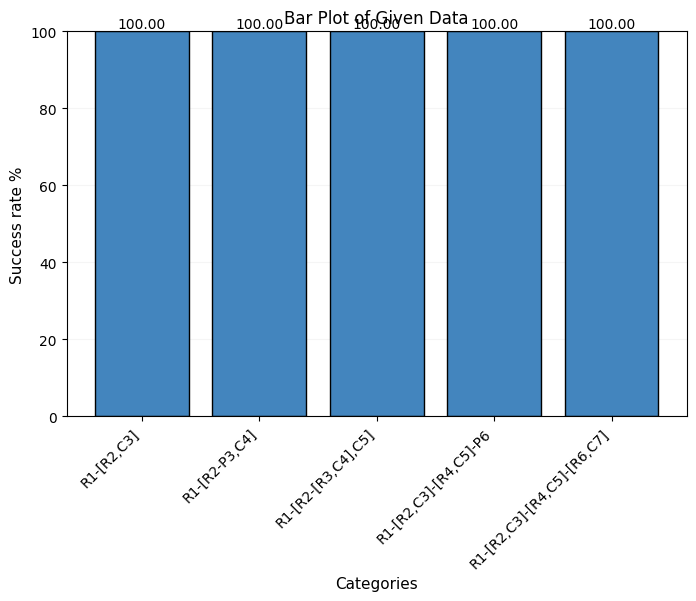

In [15]:
# Plot the Success rate for each category of EIS based on termination condition (e.g. passing the fit threshold)
state_type = dataset["true_circuit"].unique()
state_success = {}
for type_i in range(len(state_type)):
    all = len(eval_results[eval_results["ground_truth_circuit"] == state_type[type_i]])
    sucess = len(
        eval_results[
            (eval_results["ground_truth_circuit"] == state_type[type_i])
            & (eval_results["found_solution"] == 1)
        ]
    )
    percent = sucess / (all + 10e-100) * 100
    state_success[state_type[type_i]] = percent

plot_bar(state_success, color="blue")

### 5.3: Distributions of rewards and actions taken

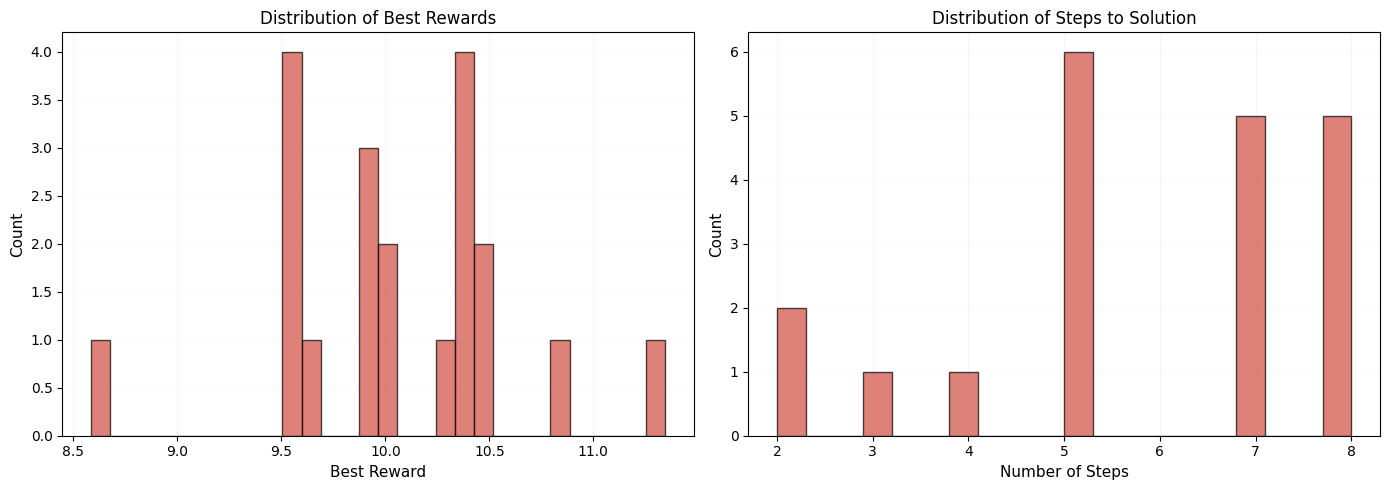

In [16]:
# Plot reward distribution
# combine these two plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: best reward distribution
ax1.hist(eval_results["best_reward"], bins=30, edgecolor="black", alpha=0.7)
ax1.set_xlabel("Best Reward")
ax1.set_ylabel("Count")
ax1.set_title("Distribution of Best Rewards")
ax1.grid(True, alpha=0.3, axis="y")

# Right: number of steps distribution
ax2.hist(eval_results["total_actions"], bins=20, edgecolor="black", alpha=0.7)
ax2.set_xlabel("Number of Steps")
ax2.set_ylabel("Count")
ax2.set_title("Distribution of Steps to Solution")
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

### Comparison with ground truth 

Note that for this section the ground truth labels should be provided for each EIS during the data preparation. Check out the `01_data_preparation_walkthrough.ipynb` to see how you can include these labels in your dataset if you already know the labels and wants to compare the circuit solution with labels. 

In [17]:
# Check if we have ground truth circuits
if "ground_truth_circuit" in eval_results.columns and "best_circuit" in eval_results.columns:
    # Show some examples
    print("\nExample comparisons:")
    print("=" * 95)
    for i in range(min(10, len(eval_results))):  # checking just the first 10 rows
        row = eval_results.iloc[i]
        print(
            f"True: {row['ground_truth_circuit']:<30s} | Found: {row['best_circuit']:<30s} | reward={row['best_reward']:.3f}"
        )
else:
    print("Ground truth circuits not available for comparison")


Example comparisons:
True: R1-[R2,C3]-[R4,C5]-P6          | Found: [P1,R2]-R3-[P4,R5-[R6,P7]]     | reward=8.585
True: R1-[R2,C3]                     | Found: R1-[P2,R3]                     | reward=11.346
True: R1-[R2,C3]-[R4,C5]-P6          | Found: [P1,R2]-R3-[P4,R5-[R6,P7]]     | reward=9.532
True: R1-[R2,C3]-[R4,C5]-[R6,C7]     | Found: [P1,R2]-R3-[P4,R5-[R6,P7]]     | reward=10.005
True: R1-[R2-[R3,C4],C5]             | Found: R1-[P2,[P3,R4]-R5]             | reward=10.242
True: R1-[R2,C3]-[R4,C5]-P6          | Found: [P1,R2]-R3-[P4,R5-[R6,P7]]     | reward=9.543
True: R1-[R2-[R3,C4],C5]             | Found: R1-[P2,[P3,R4]-R5]             | reward=10.377
True: R1-[R2-[R3,C4],C5]             | Found: R1-[P2,[P3,R4]-R5]             | reward=10.506
True: R1-[R2,C3]-[R4,C5]-[R6,C7]     | Found: [P1,R2]-R3-[P4,R5-[R6,P7]]     | reward=9.917
True: R1-[R2,C3]-[R4,C5]-P6          | Found: [P1,R2]-R3-[P4,R5-[R6,P7]]     | reward=9.664


###Optional post-processing:

Sometimes, the circuit found by the agent may still contain components that can be simplified further, e.g., two resistors or capacitors connected in series or parallel can be combined into a single equivalent component.
In this case, an optional post-processing step may be applied to simplify the circuit after it has been identified.
It may also replace constant phase elements with ideal resistors or capacitors when their exponent parameters indicate resistor-like or capacitor-like behavior.

In case you want to avoid the replacement with ideal resistors or capacitors, in the simplify( ) function, use `Pn_low = 0` and `Pn_high = 1` as the parameters.

In [18]:
from autorec.parser import (
    simplify,
)  # Import the post-processing function for circuit simplification


if "ground_truth_circuit" in eval_results.columns and "best_circuit" in eval_results.columns:
    print("\nExample comparisons:")
    print("=" * 95)
    for i in range(min(10, len(eval_results))):  # checking just the first 10 rows
        row = eval_results.iloc[i]
        gt_circuit = row["ground_truth_circuit"]
        best_circuit = row["best_circuit"]
        best_param = row["best_param"]
        simplified_circuit = simplify(best_circuit, best_param)[0]  # Simplify the circuit
        # The `simplify` function also returns the recomputed component values of the simplified circuit
        reward = row["best_reward"]
        print(
            f"True: {gt_circuit:<30s} | Found: {simplified_circuit:<30s} | reward = {reward:.3f}"
        )
else:
    print("Ground truth circuits not available for comparison")


Example comparisons:
True: R1-[R2,C3]-[R4,C5]-P6          | Found: R3-[C1,R2]-[C4,R5-[R6,P7]]     | reward = 8.585
True: R1-[R2,C3]                     | Found: R1-[C2,R3]                     | reward = 11.346
True: R1-[R2,C3]-[R4,C5]-P6          | Found: R3-[P1,R2]-[C4,R5-[R6,C7]]     | reward = 9.532
True: R1-[R2,C3]-[R4,C5]-[R6,C7]     | Found: R3-[C1,R2]-[C4,R5-[R6,C7]]     | reward = 10.005
True: R1-[R2-[R3,C4],C5]             | Found: R1-[C2,[C3,R4]-R5]             | reward = 10.242
True: R1-[R2,C3]-[R4,C5]-P6          | Found: R3-[P1,R2]-[C4,R5-[R6,C7]]     | reward = 9.543
True: R1-[R2-[R3,C4],C5]             | Found: R1-[C2,[C3,R4]-R5]             | reward = 10.377
True: R1-[R2-[R3,C4],C5]             | Found: R1-[C2,[C3,R4]-R5]             | reward = 10.506
True: R1-[R2,C3]-[R4,C5]-[R6,C7]     | Found: R3-[C1,R2]-[C4,R5-[R6,C7]]     | reward = 9.917
True: R1-[R2,C3]-[R4,C5]-P6          | Found: R3-[P1,R2]-[C4,R5-[R6,C7]]     | reward = 9.664


---
## Step 6: Save Results

In [19]:
# Save evaluation results
results_dir = Path(f"{DIR}/evaluation_results")
results_dir.mkdir(exist_ok=True)

# Save as CSV
csv_path = results_dir / "eval_results.csv"
eval_results.to_csv(csv_path, index=False)
print(f"✓ Saved results to: {csv_path}")

# Save as pickle (preserves complex data types)
pkl_path = results_dir / "eval_results.pkl"
eval_results.to_pickle(pkl_path)
print(f"✓ Saved results to: {pkl_path}")

✓ Saved results to: demo_output/evaluation_results/eval_results.csv
✓ Saved results to: demo_output/evaluation_results/eval_results.pkl


---
## Summary

You've now learned how to:

✓ Load a trained model  
✓ Use the agent on a single EIS (step-by-step)  
✓ Understand the agent's decision process  
✓ Run batch evaluation on multiple EIS  
✓ Analyze and visualize results  
✓ Compare discovered circuits vs ground truth  

## Key Takeaways

1. **Agent acts greedily during evaluation** (epsilon=0, no exploration)
2. **Each step is a mutation** of the circuit chromosome
3. **Rewards guide the agent** toward better-fitting circuits

## Tips for Using Trained Models

- Always use the **same environment configuration** as during training 
- Set **epsilon=0** during evaluation for greedy (best) actions
- **Batch evaluation** is much faster than individual evaluation
- Monitor **both R² and chi-square** for fit quality
- Save evaluation results for later analysis

---

## Next Steps

- Use your trained model on new, unseen EIS data
- Experiment with different hyperparameters and retrain
- Try different circuit element sets
- If you are using AutoREC, please consider citing the original paper.
- For questions, bugs report, and suggestions, please create an issue in the GitHub page of AutoREC.